In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

In [2]:
data = {
    "income":[60000,90000,120000,45000,75000,100000,55000,80000,70000,50000],
    "additional_income":[5000,10000,0,0,3000,15000,2000,5000,4000,0],
    "savings":[50000,150000,300000,10000,80000,250000,20000,120000,70000,5000],
    "loan_count":[3,2,4,5,3,2,4,2,3,4],
    "total_emi":[35000,25000,60000,38000,42000,30000,36000,28000,40000,45000],
    "remaining_principal":[400000,250000,600000,300000,450000,200000,350000,280000,420000,380000],
    "months_left":[36,24,60,48,30,18,40,22,34,50],
    "extra_payment_capacity":[5000,15000,20000,2000,7000,25000,3000,12000,6000,1000]
}

df = pd.DataFrame(data)
df

,income,additional_income,savings,loan_count,total_emi,remaining_principal,months_left,extra_payment_capacity
0,60000,5000,50000,3,35000,400000,36,5000
1,90000,10000,150000,2,25000,250000,24,15000
2,120000,0,300000,4,60000,600000,60,20000
3,45000,0,10000,5,38000,300000,48,2000
4,75000,3000,80000,3,42000,450000,30,7000
5,100000,15000,250000,2,30000,200000,18,25000
6,55000,2000,20000,4,36000,350000,40,3000
7,80000,5000,120000,2,28000,280000,22,12000
8,70000,4000,70000,3,40000,420000,34,6000
9,50000,0,5000,4,45000,380000,50,1000


#### EMI Ratio

In [3]:
### emi_ratio = total_emi / total_income

In [4]:
df['total_income'] = df['income']+df['additional_income']
df['emi_ratio'] = df['total_emi'] / df['total_income']

### create stress level label

In [5]:
conditions = [
    df['emi_ratio'] < 0.3,
    (df['emi_ratio'] >= 0.3) & (df['emi_ratio'] < 0.6),
    df['emi_ratio'] >= 0.6
]

choices=[0,1,2]

df['stress_level'] = np.select(conditions,choices)

df

,income,additional_income,savings,loan_count,total_emi,remaining_principal,months_left,extra_payment_capacity,total_income,emi_ratio,stress_level
0,60000,5000,50000,3,35000,400000,36,5000,65000,0.538462,1
1,90000,10000,150000,2,25000,250000,24,15000,100000,0.250000,0
2,120000,0,300000,4,60000,600000,60,20000,120000,0.500000,1
3,45000,0,10000,5,38000,300000,48,2000,45000,0.844444,2
4,75000,3000,80000,3,42000,450000,30,7000,78000,0.538462,1
5,100000,15000,250000,2,30000,200000,18,25000,115000,0.260870,0
6,55000,2000,20000,4,36000,350000,40,3000,57000,0.631579,2
7,80000,5000,120000,2,28000,280000,22,12000,85000,0.329412,1
8,70000,4000,70000,3,40000,420000,34,6000,74000,0.540541,1
9,50000,0,5000,4,45000,380000,50,1000,50000,0.900000,2


#### visualization income vs emi

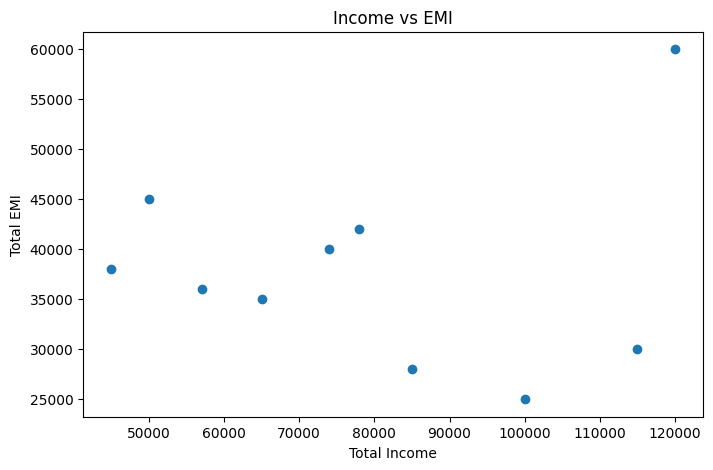

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df["total_income"], df["total_emi"])
plt.xlabel("Total Income")
plt.ylabel("Total EMI")
plt.title("Income vs EMI")
plt.show()

#### Emi ratio distribution

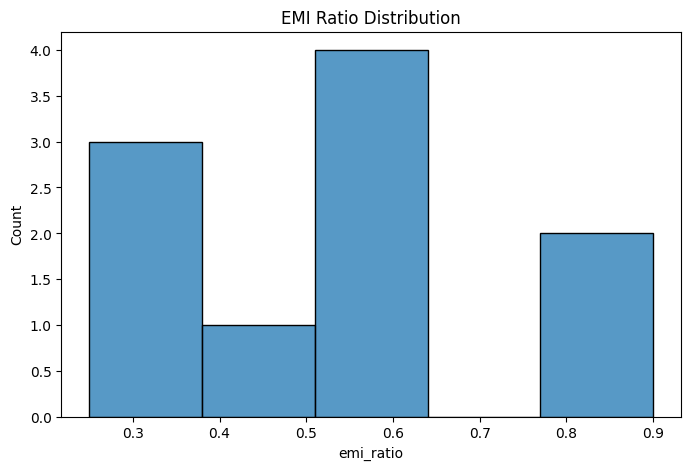

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["emi_ratio"], bins=5)
plt.title("EMI Ratio Distribution")
plt.show()

#### loan count vs emi

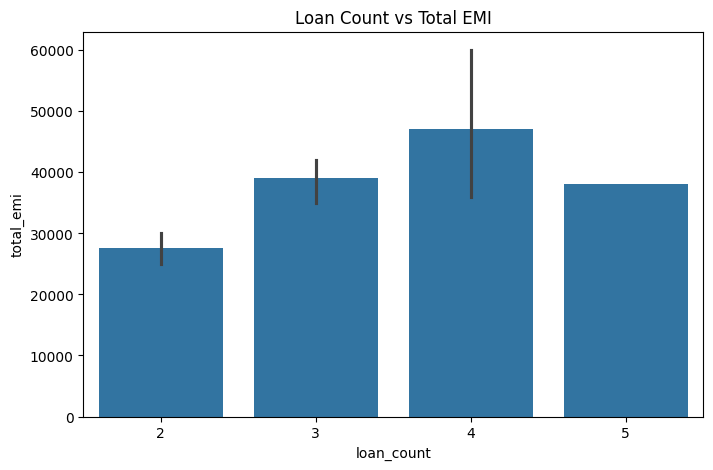

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x="loan_count", y="total_emi", data=df)
plt.title("Loan Count vs Total EMI")
plt.show()

#### stress level count

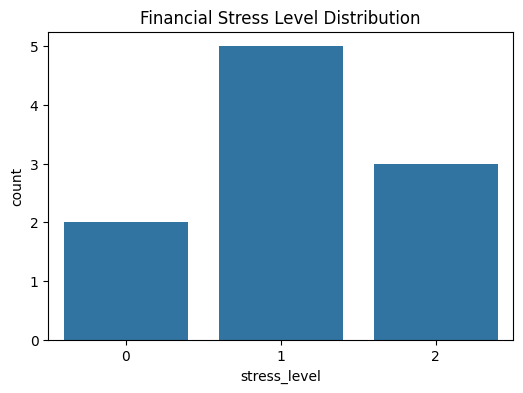

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="stress_level", data=df)
plt.title("Financial Stress Level Distribution")
plt.show()

#### correlation heatmap

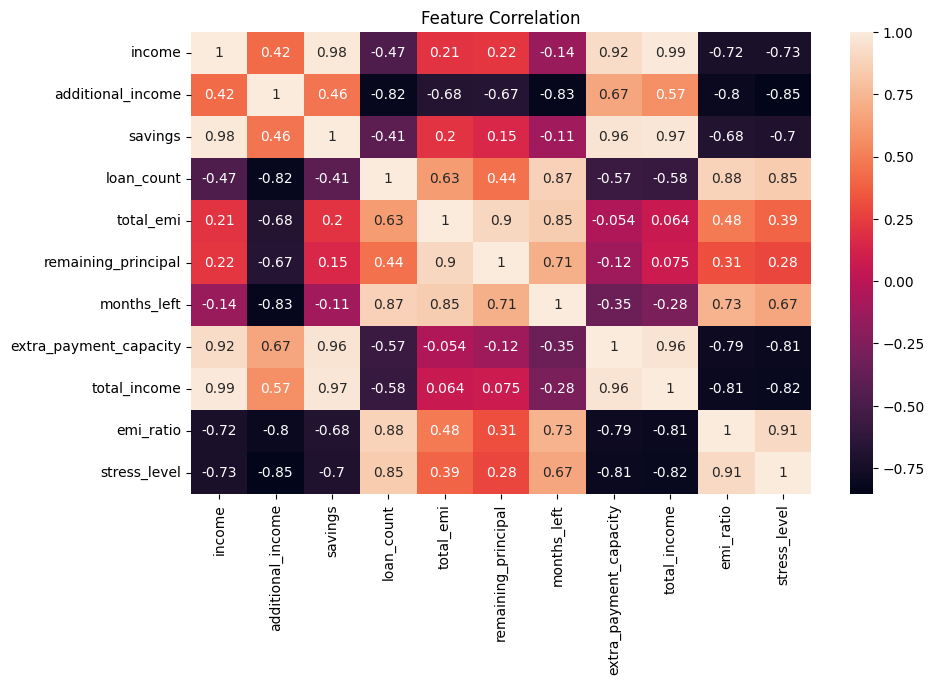

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [11]:
df.head()

,income,additional_income,savings,loan_count,total_emi,remaining_principal,months_left,extra_payment_capacity,total_income,emi_ratio,stress_level
0,60000,5000,50000,3,35000,400000,36,5000,65000,0.538462,1
1,90000,10000,150000,2,25000,250000,24,15000,100000,0.250000,0
2,120000,0,300000,4,60000,600000,60,20000,120000,0.500000,1
3,45000,0,10000,5,38000,300000,48,2000,45000,0.844444,2
4,75000,3000,80000,3,42000,450000,30,7000,78000,0.538462,1


#### prepare data for model training

In [15]:
X = df[[
"income",
"additional_income",
"loan_count",
"total_emi",
"remaining_principal",
"months_left",
"savings"
]]

y = df["stress_level"]

#### train model

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### check accuracy

In [19]:
pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 1.0


#### save model 

In [20]:
pickle.dump(model,open("finance_model.pkl","wb"))